In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from tqdm import tqdm

### Preprocess Data

In [23]:
from preprocess_data import preprocess_data
from pathlib import Path

print("Preprocessing training data...")
preprocess_data(data_dir=Path("Results/"), split="train", noise_scale=0.001)

print()
print("Preprocessing test data...")
preprocess_data(data_dir=Path("Results/"), split="val")

Preprocessing training data...
Processing trajectory: 0
Length of trajectory 0: 49
Processing trajectory: 1
Length of trajectory 1: 49
Processing trajectory: 2
Length of trajectory 2: 49
Processing trajectory: 3
Length of trajectory 3: 49
Processing trajectory: 4
Length of trajectory 4: 49
Processing trajectory: 5
Length of trajectory 5: 49
Processing trajectory: 6
Length of trajectory 6: 49
Processing trajectory: 7
Length of trajectory 7: 49
Processing trajectory: 8
Length of trajectory 8: 49
Processing trajectory: 9
Length of trajectory 9: 49
Processing trajectory: 10
Length of trajectory 10: 49
Processing trajectory: 11
Length of trajectory 11: 49
Processing trajectory: 12
Length of trajectory 12: 49
Processing trajectory: 13
Length of trajectory 13: 49
Processing trajectory: 14
Length of trajectory 14: 49
Processing trajectory: 15
Length of trajectory 15: 49
Processing trajectory: 16
Length of trajectory 16: 49
Processing trajectory: 17
Length of trajectory 17: 49
Processing trajec

### Load Dataset

In [ ]:
from in_memory_dataset import InMemoryTimeStepDataset
from torch_geometric.loader import DataLoader

train_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/train")
test_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/val")

batch_size = 16
num_workers = 4
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Found 54 sample files
Loaded the dataset with 2646 samples
Found 1 sample files
Loaded the dataset with 49 samples


### Initialize Model

In [7]:
from models.vinay_mgn import MeshGraphNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

node_channels = 10
edge_channels = 4
num_messages = 8
latent_dim = 128

model = MeshGraphNet(
    node_channels=node_channels,
    edge_channels=edge_channels,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
_ = model.to(device)

### Initialize Trainer

In [9]:
from trainer import Trainer

lr = 3e-5
loss_type = "mse"

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
trainer = Trainer(model, optimizer, device, loss_type=loss_type)
torch.cuda.empty_cache()

### Train Loop

In [10]:
from tqdm.notebook import tqdm_notebook as tqdm
from preprocess_data import Stats
import json

print("Loading stats...")
with open("Results/train/stats/stats.json", "r") as f:
    stats = json.load(f)
node_stats = Stats.from_dict(stats["node"])
edge_stats = Stats.from_dict(stats["edge"])
target_stats = Stats.from_dict(stats["target"])
dt = 0.08

total_epochs = 1

epoch_bar = tqdm(range(total_epochs), desc="Epochs")
for epoch in epoch_bar:
    for batch in tqdm(train_dataloader, desc="Batches", leave=False):
        # print("hey")
        trainer.train(batch)

    trainer.test(
        test_loader=test_dataloader,
        node_stats=node_stats,
        edge_stats=edge_stats,
        target_stats=target_stats,
        dt=dt,
    )
    trainer.epoch_end()
    trainer.save_model(epoch=epoch)
    epoch_bar.set_postfix(
        {
            "last_loss": f"{trainer.loss:.6f}, gen_loss: {trainer.gen_test_history[-1]:.6f}"
        }
    )


Loading stats...


Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

In [11]:
import numpy as np

len(train_dataloader)
epochs_indices = np.arange(
    0, total_epochs * len(train_dataloader), len(train_dataloader)
)
print(epochs_indices)

[0]


### Show Training Progress

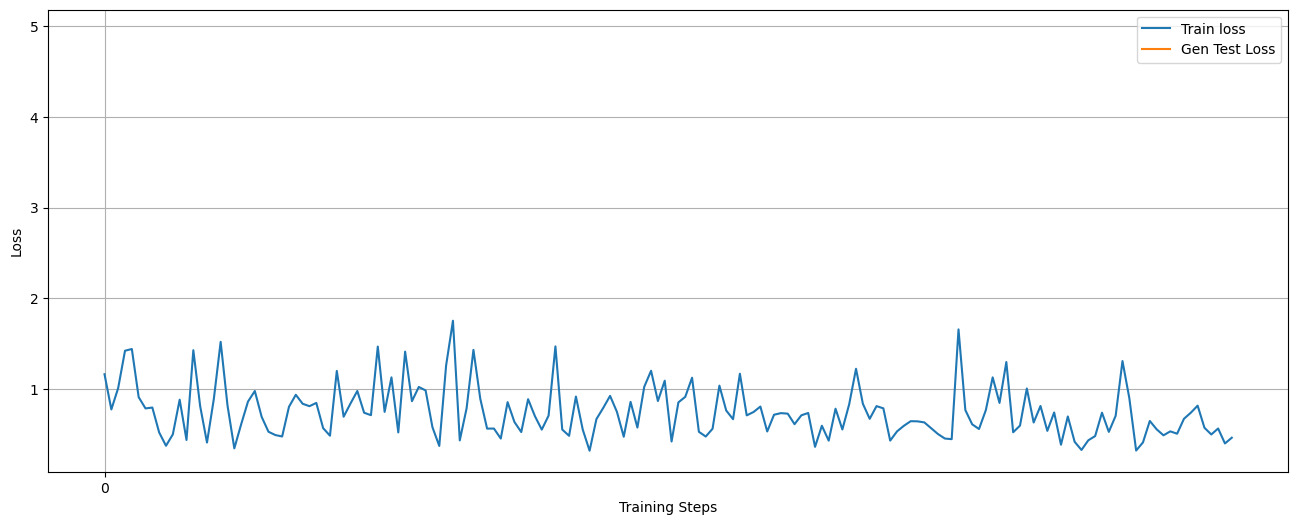

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(trainer.train_history, label="Train loss")
plt.plot(epochs_indices, trainer.gen_test_history, label="Gen Test Loss")
plt.legend()
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.xticks(epochs_indices, [str(i) for i in range(total_epochs)])
plt.grid()
plt.show()

### Show animation

In [19]:
from rollout_utils import do_rollout

model = trainer.model.eval()

error_x, error_v, error_stress, true_rollout, pred_rollout = do_rollout(
    model=model,
    test_loader=test_dataloader,
    device=trainer.device,
    node_stats=node_stats,
    edge_stats=edge_stats,
    target_stats=target_stats,
    dt=dt,
    skip_first=0,
    skip_after=15,
)

In [20]:
from make_gif import make_beam_comparison_gif


make_beam_comparison_gif(
    pred_rollout=pred_rollout,
    true_rollout=true_rollout,
    L=1.0,
    W=0.1,
    D=0.04,  # Beam dimensions
    out_gif="beam_comparison.gif",
    fps=4,
)

Rendering frame 0/15


/Users/ksteiner/github/BeamElastoDynamics/make_gif.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


Rendering frame 1/15
Rendering frame 2/15
Rendering frame 3/15
Rendering frame 4/15
Rendering frame 5/15
Rendering frame 6/15
Rendering frame 7/15
Rendering frame 8/15
Rendering frame 9/15
Rendering frame 10/15
Rendering frame 11/15
Rendering frame 12/15
Rendering frame 13/15
Rendering frame 14/15
Rendering frame 15/15
GIF saved => beam_comparison.gif
Done.


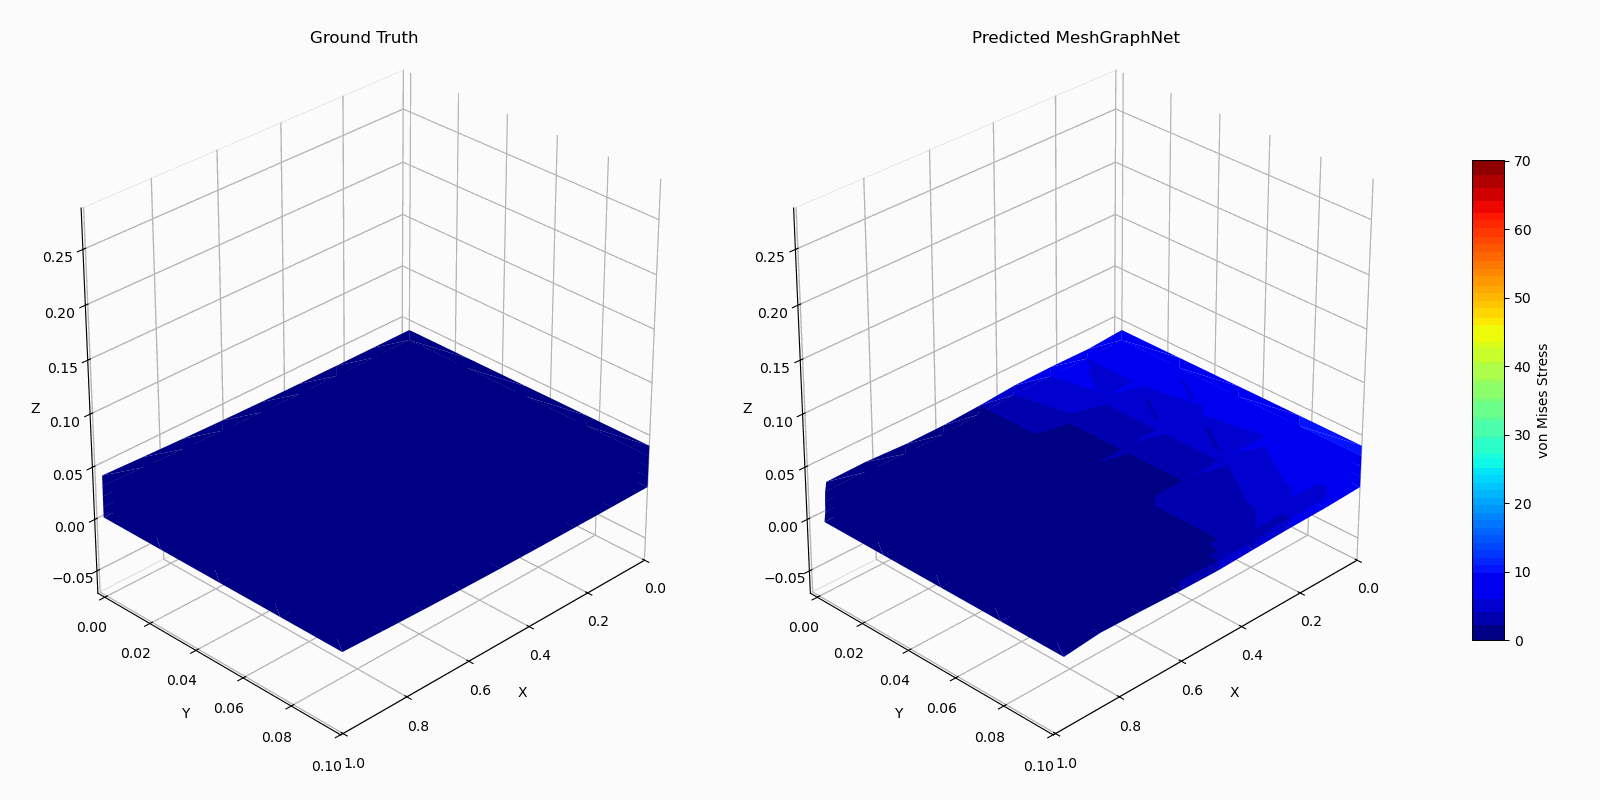

In [21]:
from IPython.display import Image

Image(filename="beam_comparison.gif")